In [2]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
from shutil import copyfile, rmtree
from tqdm import tqdm
import time

import tensorflow as tf
from tensorflow.keras import Model, layers, callbacks
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# =================== CONFIG ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60
INITIAL_LR = 5e-5
LABEL_SMOOTHING = 0.1
train_ratio = 0.7
val_ratio = 0.15

dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN OLD SPLITS ===================
if os.path.exists(base_dir):
    rmtree(base_dir)

# =================== SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS ===================
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_generator = datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

# =================== MODEL ===================
def build_model():
    base_model = InceptionResNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Keep base frozen for slow training

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_model()

# =================== COMPILE ===================
loss_fn = CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)
optimizer = Adam(learning_rate=INITIAL_LR)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# =================== PARAMETER COUNT ===================
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
print(f"\n📊 Trainable parameters: {trainable_params:,}")
print(f"📊 Non-trainable parameters: {non_trainable_params:,}")
print(f"📊 Total parameters: {trainable_params + non_trainable_params:,}\n")

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'inceptionresnetv2.keras', monitor='val_loss', save_best_only=True, verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

# =================== TRAIN ===================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_time = end_time - start_time
avg_epoch_time = total_time / len(history.history['loss'])

print(f"\n⏱️ Total Training Time: {total_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")

# =================== EVALUATE ===================
model.load_weights("inceptionresnetv2.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")


1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:01<00:00, 126.83it/s]

Found 4200 images belonging to 4 classes.


Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


I0000 00:00:1751558889.487554      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751558889.488270      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

📊 Trainable parameters: 197,252
📊 Non-trainable parameters: 54,336,736
📊 Total parameters: 54,533,988



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1751558920.864781     121 service.cc:148] XLA service 0x7cd344002730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751558920.865768     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1751558920.865797     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1751558925.372927     121 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1751558933.721187     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3689 - loss: 1.7534
Epoch 1: val_loss improved from inf to 0.86609, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 91s 407ms/step - accuracy: 0.3697 - loss: 1.7507 - val_accuracy: 0.7689 - val_loss: 0.8661
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6599 - loss: 0.9817
Epoch 2: val_loss improved from 0.86609 to 0.73528, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 26s 199ms/step - accuracy: 0.6601 - loss: 0.9814 - val_accuracy: 0.8511 - val_loss: 0.7353
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7396 - loss: 0.8627
Epoch 3: val_loss improved from 0.73528 to 0.67336, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.7397 - loss: 0.8626 - val_accuracy: 0.8744 - val_loss: 0.6734
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7996 - loss: 0.7721
Epoch 4: val_loss improved 

29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 623ms/step


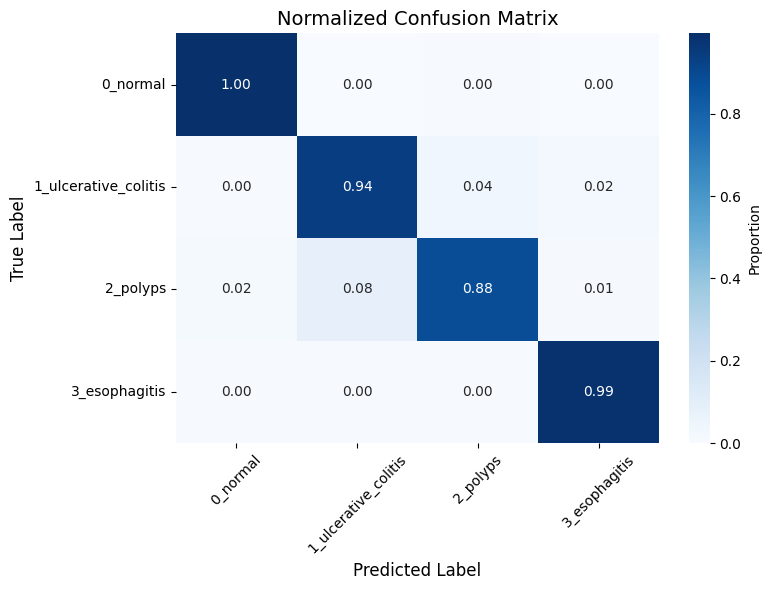

Classification Report:
                      precision    recall  f1-score   support

            0_normal       0.97      1.00      0.98       225
1_ulcerative_colitis       0.91      0.94      0.93       225
            2_polyps       0.95      0.88      0.92       225
       3_esophagitis       0.97      0.99      0.98       225

            accuracy                           0.95       900
           macro avg       0.95      0.95      0.95       900
        weighted avg       0.95      0.95      0.95       900



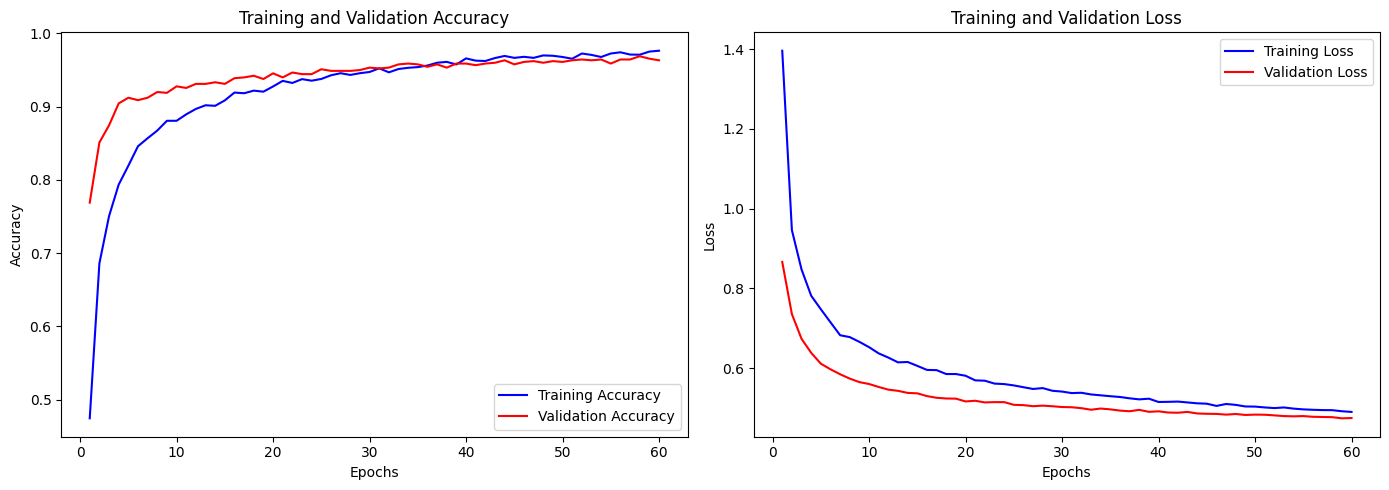

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
class_labels = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Proportion'})

plt.title("Normalized Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ============ CLASSIFICATION REPORT ============
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# ============ ACCURACY & LOSS CURVES ============
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)
